In [24]:
#import useful python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time

In [25]:
#load dataset
df=pd.read_parquet('new_masked_object.parquet')

In [26]:
#check dataset
df


,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
0,ZTF17aaafglk,22.733957,2,2.461074e+06,18.219936,1141,43.682294,0.073630,CataclyV*
1,ZTF18abavrhi,13.862530,2,2.461074e+06,16.578445,2212,244.787948,0.052932,CataclyV*
2,ZTF18acqxpid,-0.161225,2,2.461059e+06,18.902857,1094,120.643249,0.121745,CataclyV*
3,ZTF17aabsjcc,69.741185,2,2.461052e+06,17.685396,3032,67.679096,0.058235,CataclyV*
4,ZTF18abpprml,44.076774,2,2.461052e+06,19.825302,1235,91.110824,0.188079,CataclyV*
...,...,...,...,...,...,...,...,...,...
936921,ZTF18acignnq,10.637594,2,2.461084e+06,16.735125,843,298.666294,0.052518,Unknown
936922,ZTF21aageiie,-5.146635,1,2.461073e+06,15.013954,112,42.846437,0.064213,Unknown
936923,ZTF18aairqhf,16.401699,2,2.461073e+06,17.714146,3422,92.159086,0.076830,Unknown
936924,ZTF18acyxksn,-3.204930,2,2.461073e+06,15.386559,216,166.524802,0.048081,Unknown


In [27]:
#make two different arrays
cv_df = df[df["finkclass"].str.contains("CataclyV")]
unknown_df = df[df["finkclass"] == "Unknown"]

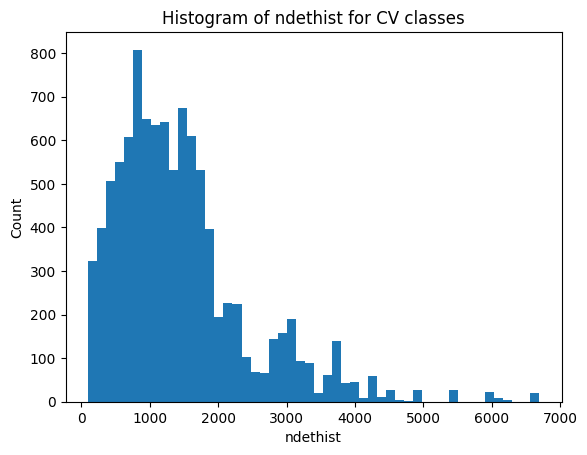

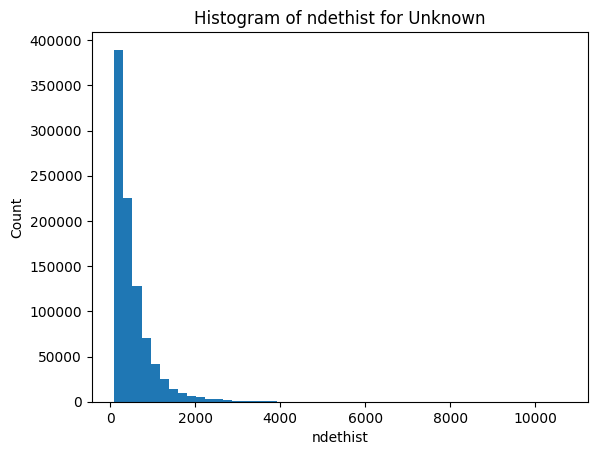

In [28]:
# CV classes histogram
plt.hist(cv_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for CV classes")
plt.xlabel("ndethist")
plt.ylabel("Count")
plt.show()

# Unknown histogram
plt.hist(unknown_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for Unknown")
plt.xlabel("ndethist")
plt.ylabel("Count")
plt.show()

In [29]:
#check the elements
df['finkclass'].unique()

['CataclyV*', 'CataclyV*_Candidate', 'Unknown']
Categories (5, object): ['Blazar', 'CataclyV*', 'CataclyV*_Candidate', 'Unknown', 'WhiteDwarf_Candidate']

In [30]:
#count of element distribution
print(df['finkclass'].value_counts())
print("Total objects:", len(df))

finkclass
Unknown                 926983
CataclyV*                 9894
CataclyV*_Candidate         49
Blazar                       0
WhiteDwarf_Candidate         0
Name: count, dtype: int64
Total objects: 936926


In [40]:
#picking subset
df['finkclass'] = df['finkclass'].str.strip()
unknown_sample = df[df['finkclass'] == 'Unknown'] \
                    .sample(n=4000, random_state=42)

cataclyv_sample = df[df['finkclass'] == 'CataclyV*'] \
                     .sample(n=2000, random_state=42)

candidate_sample = df[df['finkclass'] == 'CataclyV*_Candidate']
# No sampling needed since total = 49

In [41]:
#saving
final_df = pd.concat(
    [unknown_sample, cataclyv_sample, candidate_sample]
)

In [42]:
#double check
print(final_df['finkclass'].value_counts())
print("Total:", len(final_df))

finkclass
Unknown                4000
CataclyV*              2000
CataclyV*_Candidate      49
Name: count, dtype: int64
Total: 6049


In [34]:
#concatination
final_df.to_parquet("subset_sample_1.parquet", index=False)

In [43]:
#dataset
final_df

,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
555,ZTF22abkbkwf,3.351453,2,2.461095e+06,20.202946,346,127.088550,0.203812,Unknown
3491,ZTF19aaipnea,-8.114515,1,2.461059e+06,18.689606,181,96.470421,0.132327,Unknown
527,ZTF18abzjvuq,22.989689,1,2.461052e+06,17.183928,481,86.289874,0.060725,Unknown
3925,ZTF19aaaimeb,-11.608407,1,2.461059e+06,18.300737,433,100.543662,0.102906,Unknown
2989,ZTF20acqmgod,-19.330276,2,2.461072e+06,17.086111,345,66.149625,0.087255,Unknown
...,...,...,...,...,...,...,...,...,...
6044,ZTF18acclkfa,1.988866,1,2.461076e+06,19.751032,830,99.710718,0.183764,CataclyV*_Candidate
6045,ZTF18acclkfa,1.988860,2,2.461081e+06,19.318232,842,99.710736,0.113419,CataclyV*_Candidate
6046,ZTF18acclkfa,1.988891,1,2.461096e+06,19.521490,858,99.710692,0.144407,CataclyV*_Candidate
6047,ZTF18acclkfa,1.988851,1,2.461080e+06,20.225601,840,99.710635,0.197120,CataclyV*_Candidate


In [37]:
#for rband elements

df = pd.read_parquet("subset_sample_1.parquet")

count_rband = (df["fid"] == 2).sum()

print("Number of rows with fid = 2:", count_rband)

Number of rows with fid = 2: 3246


In [39]:
#crosscheck
df

,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
0,ZTF18abasypy,48.685672,1,2.461056e+06,19.157499,333,332.939359,0.212721,Unknown
1,ZTF18actgxcg,-5.145224,1,2.461080e+06,19.509388,360,114.963365,0.142426,Unknown
2,ZTF19aaeamsj,8.027349,2,2.461050e+06,18.203617,423,93.681281,0.140484,Unknown
3,ZTF18aafvqcf,12.338726,1,2.461056e+06,16.958902,427,111.270535,0.068800,Unknown
4,ZTF19aaxuzqt,-1.728300,2,2.461074e+06,17.484552,155,274.781846,0.115772,Unknown
...,...,...,...,...,...,...,...,...,...
6044,ZTF18acclkfa,1.988866,1,2.461076e+06,19.751032,830,99.710718,0.183764,CataclyV*_Candidate
6045,ZTF18acclkfa,1.988860,2,2.461081e+06,19.318232,842,99.710736,0.113419,CataclyV*_Candidate
6046,ZTF18acclkfa,1.988891,1,2.461096e+06,19.521490,858,99.710692,0.144407,CataclyV*_Candidate
6047,ZTF18acclkfa,1.988851,1,2.461080e+06,20.225601,840,99.710635,0.197120,CataclyV*_Candidate


In [44]:
#print unique
print("Unique objects:", final_df["objectId"].nunique())

Unique objects: 4699


In [15]:
# Load dataset (only first 5 rows for testing)
df_test = pd.read_parquet("subset_sample_1.parquet").head(5)

print("Total rows:", len(df_test))
# Group by objectId
groups = df_test.groupby("objectId")

all_rows = []
# Process objects
for i, (object_id, group) in enumerate(groups):

    print(f"Processing {i+1}: {object_id}")

    # Extract metadata
    ra = group["ra"].iloc[0]
    dec = group["dec"].iloc[0]
    finkclass = group["finkclass"].iloc[0]

    try:
        # Query SNAD
        
        url = "https://db.ztf.snad.space/api/v3/data/latest/circle/full/json"

        params = {
            "ra": ra,
            "dec": dec,
            "radius_arcsec": 1.2
        }

        r = requests.get(url, params=params)
        r.raise_for_status()

        data = r.json()

        if len(data) == 0:
            continue
        # Extract light curve
       
        for name in data:

            lc = data[name].get("lc", [])
            #filt = data[name].get("meta", {}).get("filter", None)

            for point in lc:

                all_rows.append({
                    "objectId": object_id,
                    "finkclass": finkclass,
                    "oid": name,
                    "mjd": point.get("mjd"),
                    "mag": point.get("mag"),
                    "magerr": point.get("magerr"),
                    #"filter": filt
                })

    except Exception as e:
        print("Error fetching", object_id, e)

    time.sleep(0.5)

# Create dataframe

final_df = pd.DataFrame(all_rows)

print("Total photometry rows collected:", len(final_df))


# group
grouped_df = final_df.groupby("objectId").agg({
    "finkclass": "first",
    "oid": "first",
    #"filter": list,
    "mjd": list,
    "mag": list,
    "magerr": list
}).reset_index()

print("Objects after grouping:", len(grouped_df))

# Save output

grouped_df.to_parquet("snad_lightcurves_grouped_1.parquet")

print("Saved file: snad_lightcurves_grouped_1.parquet")

# Display result


print(grouped_df.head())

Total rows: 5
Processing 1: ZTF18aafvqcf
Processing 2: ZTF18abasypy
Processing 3: ZTF18actgxcg
Processing 4: ZTF19aaeamsj
Processing 5: ZTF19aaxuzqt
Total photometry rows collected: 6478
Objects after grouping: 5
Saved file: snad_lightcurves_grouped_1.parquet
       objectId finkclass              oid  \
0  ZTF18aafvqcf   Unknown  515112400004281   
1  ZTF18abasypy   Unknown  770110300032659   
2  ZTF18actgxcg   Unknown  412102200009037   
3  ZTF19aaeamsj   Unknown  460116100005044   
4  ZTF19aaxuzqt   Unknown  435112400037909   

                                                 mjd  \
0  [58227.18626, 58235.19538, 58238.16412, 58368....   
1  [58234.41965, 58234.50106, 58235.49942, 58236....   
2  [58204.1857, 58204.19968, 58207.21958, 58207.2...   
3  [58204.13351, 58204.17896, 58205.15103, 58206....   
4  [58205.47309, 58205.52777, 58206.44695, 58207....   

                                                 mag  \
0  [14.547056, 14.508276, 14.515644, 14.495608, 1...   
1  [17.055824,

In [16]:
#concatinated long grouped lc
final_df=pd.read_parquet('snad_lightcurves_grouped.parquet')

In [17]:
#lc
final_df

,objectId,finkclass,oid,filter,mjd,mag,magerr
0,ZTF17aaaadkj,CataclyV*,743102100005228,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.12504, 58204.16156, 58206.12473, 58206....","[18.212118, 18.1215, 18.324465, 18.40276, 18.2...","[0.033463914, 0.03208954, 0.035320017, 0.03672..."
1,ZTF17aaaahaw,Unknown,741109200012360,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58206.14293, 58206.1627, 58307.45164, 58312.4...","[16.410797, 16.408834, 16.364986, 16.377684, 1...","[0.016678985, 0.016671574, 0.016509822, 0.0165..."
2,ZTF17aaaarmr,CataclyV*,703106200000801,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58206.12602, 58206.14519, 58207.24488, 58210....","[16.625607, 16.585968, 16.463081, 16.486929, 1...","[0.020074423, 0.01985601, 0.01924174, 0.019353..."
3,ZTF17aaaazob,CataclyV*,651109400004459,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58275.46801, 58280.44675, 58283.44612, 58286....","[18.443819, 17.906633, 17.686993, 17.911257, 1...","[0.04150144, 0.028805345, 0.025153672, 0.02889..."
4,ZTF17aaabarf,CataclyV*,659116100012537,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.12748, 58204.1719, 58205.12678, 58205.1...","[14.48788, 14.473833, 14.393332, 14.38434, 14....","[0.0137337595, 0.0137162125, 0.013617599, 0.01..."
...,...,...,...,...,...,...,...
4542,ZTF26aaaqcza,Unknown,583101100018631,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58203.4213, 58206.41237, 58206.45325, 58210.3...","[17.51718, 17.543804, 17.515045, 17.61259, 17....","[0.01983606, 0.020126376, 0.019813115, 0.02091..."
4543,ZTF26aaatgya,Unknown,776105100008983,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58206.14129, 58302.44461, 58304.46878, 58305....","[17.86646, 17.820587, 17.937817, 18.038612, 17...","[0.028641524, 0.028094644, 0.02954351, 0.03093..."
4544,ZTF26aabajgm,Unknown,259116200001773,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.18578, 58423.46124, 58427.50438, 58430....","[16.270721, 16.098993, 16.08963, 16.152328, 16...","[0.017157847, 0.016382389, 0.016343957, 0.0166..."
4545,ZTF26aadqsco,Unknown,711104100007340,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58248.1769, 58432.49375, 58468.43809, 58469.5...","[21.583458, 21.566477, 21.755232, 21.67491, 21...","[0.25615883, 0.25473356, 0.2705766, 0.26383483..."


In [18]:
zr_objects = final_df[final_df["filter"].apply(lambda x: "zr" in x)]

print(zr_objects.head())
print("Total objects with zr:", len(zr_objects))

       objectId  finkclass              oid  \
0  ZTF17aaaadkj  CataclyV*  743102100005228   
1  ZTF17aaaahaw    Unknown  741109200012360   
2  ZTF17aaaarmr  CataclyV*  703106200000801   
3  ZTF17aaaazob  CataclyV*  651109400004459   
4  ZTF17aaabarf  CataclyV*  659116100012537   

                                              filter  \
0  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
1  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
2  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
3  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
4  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   

                                                 mjd  \
0  [58204.12504, 58204.16156, 58206.12473, 58206....   
1  [58206.14293, 58206.1627, 58307.45164, 58312.4...   
2  [58206.12602, 58206.14519, 58207.24488, 58210....   
3  [58275.46801, 58280.44675, 58283.44612, 58286....   
4  [58204.12748, 58204.1719, 58205.12678, 58205.1...   

                                           

In [19]:
zr_objects.to_parquet("snad_lightcurves_r_band.parquet")

print("Saved: snad_lightcurves_zr_only.parquet")

Saved: snad_lightcurves_zr_only.parquet


In [20]:
import light_curve as lc
# Load grouped lightcurve file
df_new = pd.read_parquet("snad_lightcurves_r_band.parquet")

print("Total objects:", len(df_new))
# Define feature extractor
extractor = lc.Extractor(
    lc.Mean(),
    lc.WeightedMean(),
    lc.StandardDeviation(),
    lc.Median(),
    lc.Amplitude(),
    lc.BeyondNStd(nstd=1),
    lc.Cusum(),
    lc.InterPercentileRange(0.10),
    lc.Kurtosis(),
    lc.LinearTrend(),
    lc.LinearFit(),
    lc.MagnitudePercentageRatio(0.4, 0.05),
    lc.MagnitudePercentageRatio(0.2, 0.1),
    lc.MaximumSlope(),
    lc.MedianAbsoluteDeviation(),
    lc.MedianBufferRangePercentage(0.10),
    lc.PercentAmplitude(),
    lc.MeanVariance(),
    lc.AndersonDarlingNormal(),
    lc.ReducedChi2(),
    lc.Skew(),
    lc.StetsonK()
)
# Feature extraction
results = []

for _, row in df_new.iterrows():

    try:
        t = np.array(row["mjd"])
        m = np.array(row["mag"])
        err = np.array(row["magerr"])

        feats = extractor(t, m, err, sorted=True, check=False)

        results.append(
            [row["objectId"], row["finkclass"]] + list(feats)
        )

    except Exception as e:
        print(f"Skipping {row['objectId']} due to error: {e}")

# Create dataframe
features_df = pd.DataFrame(
    results,
    columns=["objectId", "finkclass"] + extractor.names
)

# Save feature space
features_df.to_parquet("new_feature_space.parquet", index=False)

print("Feature extraction complete!")
print("Saved to: new_feature_space.parquet")
print("Shape:", features_df.shape)

Total objects: 4495
Feature extraction complete!
Saved to: new_feature_space.parquet
Shape: (4495, 28)


In [21]:
df=pd.read_parquet("new_feature_space.parquet")

In [22]:
df.keys()

Index(['objectId', 'finkclass', 'mean', 'weighted_mean', 'standard_deviation',
       'median', 'amplitude', 'beyond_1_std', 'cusum',
       'inter_percentile_range_10', 'kurtosis', 'linear_trend',
       'linear_trend_sigma', 'linear_trend_noise', 'linear_fit_slope',
       'linear_fit_slope_sigma', 'linear_fit_reduced_chi2',
       'magnitude_percentage_ratio_40_5', 'magnitude_percentage_ratio_20_10',
       'maximum_slope', 'median_absolute_deviation',
       'median_buffer_range_percentage_10', 'percent_amplitude',
       'mean_variance', 'anderson_darling_normal', 'chi2', 'skew',
       'stetson_K'],
      dtype='object')